# Feature Extraction

## Overview

This notebook converts the generated Canny sketch images into numerical feature vectors for classical machine learning models.

The previous notebook created sketch-like edge images for the balanced prototype dataset. Here, these sketch images are loaded and prepared for feature extraction.

The main feature representation will be HOG(Histogram of Oriented Gradients), because the sketch images mainly contain contours, edges, and shape boundaries.

The output of this notebook will be saved feature arrays that can be used in the classification notebook, for SVM training and evaluation.

## Setup and Imports

In [5]:
from pathlib import Path
import sys

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from skimage.feature import hog
from skimage import exposure
from tqdm import tqdm

sys.path.append("..")

%reload_ext autoreload
%autoreload 2

from src import utils
from src import feature_extraction

pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 100

print("Libraries loaded successfully")

Libraries loaded successfully


## Load Metadata with Sketch Paths

The updated metadata from Notebook 02 is loaded here. This file contains the original image paths, class labels, dataset splits, and the generated Canny sketch paths.

Before extracting features, the sketch paths are checked to confirm that all generated files exist.

In [2]:
metadata_path = utils.SPLITS_DIR / "prototype_500_per_class_with_sketches.csv"
df = pd.read_csv(metadata_path)

# Restore Path objects
df["path"] = df["path"].apply(Path)
df["canny_sketch_path"] = df["canny_sketch_path"].apply(Path)

print(f"Metadata loaded: {len(df)} images")
print(f"Columns: {df.columns.tolist()}")
df.head()

Metadata loaded: 2500 images
Columns: ['split', 'path', 'relative_path', 'category', 'class_name', 'style', 'canny_sketch_path']


,split,path,relative_path,category,class_name,style,canny_sketch_path
0,train,C:\Users\Vanya\PycharmProjects\PythonProject\S...,houzz/tables/Industrial/35489industrial-dining...,tables,table,Industrial,C:\Users\Vanya\PycharmProjects\PythonProject\S...
1,train,C:\Users\Vanya\PycharmProjects\PythonProject\S...,houzz/sofas/Transitional/2428transitional-sofa...,sofas,sofa,Transitional,C:\Users\Vanya\PycharmProjects\PythonProject\S...
2,train,C:\Users\Vanya\PycharmProjects\PythonProject\S...,houzz/sofas/Transitional/1488transitional-sofa...,sofas,sofa,Transitional,C:\Users\Vanya\PycharmProjects\PythonProject\S...
3,test,C:\Users\Vanya\PycharmProjects\PythonProject\S...,houzz/dressers/Transitional/1623transitional-d...,dressers,dresser,Transitional,C:\Users\Vanya\PycharmProjects\PythonProject\S...
4,train,C:\Users\Vanya\PycharmProjects\PythonProject\S...,houzz/tables/Modern/9640modern-side-tables-and...,tables,table,Modern,C:\Users\Vanya\PycharmProjects\PythonProject\S...


## Verify Sketch Files

Before extracting features, the generated Canny sketch paths are checked to confirm that all sketch files exist locally.

This step ensures that the feature extraction loop will not fail because of missing generated images.

In [3]:
missing = df[~df["canny_sketch_path"].apply(lambda p: p.exists())]

print(f"Total sketches expected: {len(df)}")
print(f"Sketches found on disk: {len(df) - len(missing)}")
print(f"Missing sketches: {len(missing)}")

Total sketches expected: 2500
Sketches found on disk: 2500
Missing sketches: 0


In [4]:
print("Class distribution:")
print(df["class_name"].value_counts())

print("\nSplit distribution:")
print(df["split"].value_counts())

print("\nSplit x class distribution:")
display(pd.crosstab(df["split"], df["class_name"]))

Class distribution:
class_name
table      500
sofa       500
dresser    500
chair      500
bed        500
Name: count, dtype: int64

Split distribution:
split
train    1750
test      375
val       375
Name: count, dtype: int64

Split x class distribution:


class_name,bed,chair,dresser,sofa,table
split,,,,,
test,75,75,75,75,75
train,350,350,350,350,350
val,75,75,75,75,75


### Observation

All generated Canny sketch files are available. The balanced prototype structure is preserved: 500 images per class and 2,500 images in total, split into train, validation, and test subsets.

This confirms that the feature extraction stage can proceed using the saved sketch images from Notebook 02.

## Feature Extraction Strategy

The generated Canny sketches are still image files, but classical machine learning models require numerical feature vectors. This notebook therefore converts each sketch image into one or more fixed-length numerical representations.

The first and most important representation is **HOG** because it describes local edge and gradient orientation patterns. Since the input images are already sketch-like edge images, HOG is a natural choice for capturing furniture contours, legs, drawers, backs, shelves, and silhouettes.

Other feature ideas, such as raw pixel features and PCA-reduced features, are kept as planned extensions. The main goal of this notebook is first to extract and save HOG features for all prototype sketches.

## Raw Pixel Features *(planned)*

## HOG Feature Extraction

HOG stands for Histogram of Oriented Gradients. It converts an image into a numerical feature vector by describing local gradient direction patterns.

This is suitable for this project because the generated Canny sketches mainly contain furniture contours, silhouettes, legs, drawers, shelves, backs, and other shape boundaries.

The HOG representation will be used as the main feature set for the first classical machine learning classifier.

In [7]:
sample_row = df.sample(1, random_state=utils.RANDOM_STATE).iloc[0]

sketch = feature_extraction.load_grayscale_image(sample_row["canny_sketch_path"])

features, hog_image = feature_extraction.extract_hog_features(
    sketch,
    visualize=True
)

print(f"Class: {sample_row['class_name']}")
print(f"Sketch shape: {sketch.shape}")
print(f"HOG feature vector length: {len(features)}")

Class: sofa
Sketch shape: (128, 128)
HOG feature vector length: 8100


### Observation

The single-image HOG test confirms that the feature extraction function works correctly.

The input sketch has shape **128×128** pixels. With the current HOG settings, each sketch is converted into a fixed-length vector of **8,100 numerical features**. This fixed-length representation can be used as input for classical machine learning models.

### HOG Feature Vector Size

The length of the HOG feature vector is determined by the image size and the HOG parameters.

For an image of size $H \times W$, the number of cells along the vertical and horizontal dimensions is:

$$
n_{cells,y} = \frac{H}{p_y}
$$

$$
n_{cells,x} = \frac{W}{p_x}
$$

where $p_y$ and $p_x$ are the cell sizes in pixels.

Blocks are formed by sliding a window of `cells_per_block` over the cell grid with a step of one cell. Therefore, the number of blocks along each dimension is:

$$
n_{blocks,y} = n_{cells,y} - c_y + 1
$$

$$
n_{blocks,x} = n_{cells,x} - c_x + 1
$$

where $c_y$ and $c_x$ are the numbers of cells per block along each dimension.

Each block contains:

$$
c_y \times c_x
$$

cells, and each cell contributes one histogram with `orientations` bins.

The total HOG feature length is therefore:

$$
L = n_{blocks,y} \times n_{blocks,x} \times c_y \times c_x \times orientations
$$

For this project, the values are:

- image size: $128 \times 128$
- `pixels_per_cell = (8, 8)`
- `cells_per_block = (2, 2)`
- `orientations = 9`

So:

$$
n_{cells,y} = n_{cells,x} = \frac{128}{8} = 16
$$

$$
n_{blocks,y} = n_{blocks,x} = 16 - 2 + 1 = 15
$$

$$
L = 15 \times 15 \times 2 \times 2 \times 9 = 8100
$$

This matches the feature vector length produced by the single-image test above.

## HOG Visualization

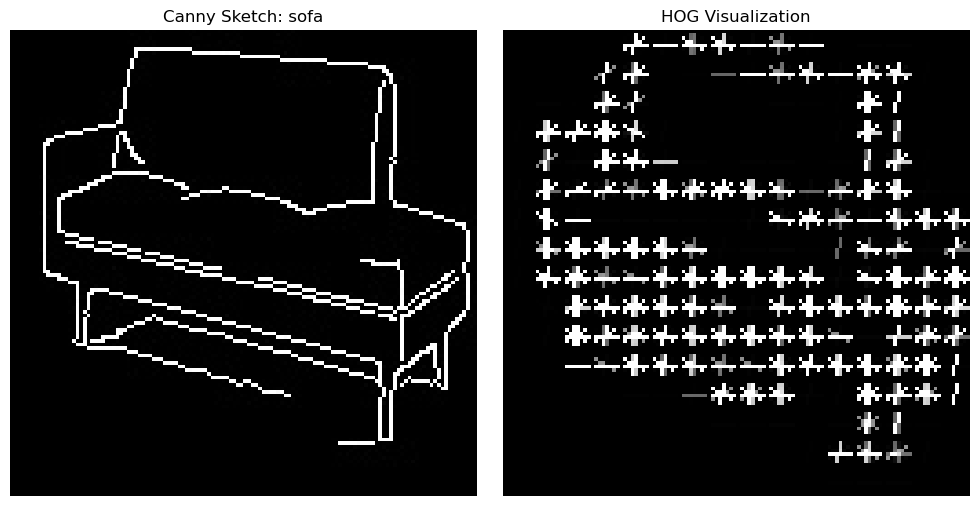

Figure saved to: C:\Users\Vanya\PycharmProjects\PythonProject\SoftUni-Studies\Furniture-Sketch-Classifier\outputs\figures\hog_visualization_example.png


In [8]:
hog_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(sketch, cmap="gray")
axes[0].set_title(f"Canny Sketch: {sample_row['class_name']}")
axes[0].axis("off")

axes[1].imshow(hog_rescaled, cmap="gray")
axes[1].set_title("HOG Visualization")
axes[1].axis("off")

plt.tight_layout()

fig_path = utils.FIGURES_DIR / "hog_visualization_example.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Figure saved to: {fig_path}")

### Observation

The HOG visualization shows how the Canny sketch is transformed into local gradient-orientation patterns. Instead of using the sketch pixels directly, HOG summarizes the direction and strength of local edge structures across small image regions.

The main sofa structure is still visible in the HOG representation, especially the backrest, seat boundary, arm shape, and vertical side contours. This confirms that HOG preserves useful shape information from the sketch image.

The visualization is not meant to reproduce the original sketch exactly. Its purpose is to show the local orientation patterns that will become the numerical feature vector used by the classifier.

## Extract HOG Features for All Sketches

The single-image test confirmed that HOG extraction works and produces a fixed-length vector of 8,100 features. The same process is now applied to all generated Canny sketches in the prototype dataset.

For each image, the notebook stores:

- the HOG feature vector;
- the class label;
- the dataset split;
- the relative image path.

In [9]:
X_hog = []
y = []
splits = []
relative_paths = []

failed = []

for _, row in tqdm(df.iterrows(), total=len(df)):
    sketch = feature_extraction.load_grayscale_image(row["canny_sketch_path"])

    if sketch is None:
        failed.append(row["relative_path"])
        continue

    features = feature_extraction.extract_hog_features(sketch)

    X_hog.append(features)
    y.append(row["class_name"])
    splits.append(row["split"])
    relative_paths.append(row["relative_path"])

X_hog = np.array(X_hog)
y = np.array(y)
splits = np.array(splits)
relative_paths = np.array(relative_paths)

print(f"HOG feature matrix shape: {X_hog.shape}")
print(f"Labels shape: {y.shape}")
print(f"Splits shape: {splits.shape}")
print(f"Relative paths shape: {relative_paths.shape}")
print(f"Failed images: {len(failed)}")

100%|██████████| 2500/2500 [00:28<00:00, 88.86it/s] 


HOG feature matrix shape: (2500, 8100)
Labels shape: (2500,)
Splits shape: (2500,)
Relative paths shape: (2500,)
Failed images: 0


### Observation

The HOG extraction loop completed successfully for all 2,500 sketch images.

Each row in `X_hog` represents one sketch image, and each sketch is described by **8,100 HOG features**. The label array `y`, split array, and relative path array preserve the class, train/validation/test split, and original image identity for each feature vector.

No images failed during feature extraction, so the HOG feature matrix is ready to be saved and used in the classification notebook.

## PCA Feature Experiment *(planned)*

## Save Feature Arrays

In [10]:
features_dir = utils.DATA_DIR / "features"
features_dir.mkdir(parents=True, exist_ok=True)

np.save(features_dir / "X_hog.npy", X_hog)
np.save(features_dir / "y.npy", y)
np.save(features_dir / "splits.npy", splits)
np.save(features_dir / "relative_paths.npy", relative_paths)

print(f"Features saved to: {features_dir}")
print(f"X_hog file size: {(features_dir / 'X_hog.npy').stat().st_size / (1024 ** 2):.2f} MB")

Features saved to: C:\Users\Vanya\PycharmProjects\PythonProject\SoftUni-Studies\Furniture-Sketch-Classifier\data\features
X_hog file size: 154.50 MB


### Observation

The HOG feature arrays were saved locally under `data/features/`.

The main feature matrix `X_hog` contains 2,500 rows and 8,100 columns. Each row represents one sketch image, and each column represents one HOG feature.

## Summary and Next Steps

This notebook converted the generated Canny sketch images into numerical HOG feature vectors.

Main outcomes:

- The metadata with generated sketch paths was loaded successfully.
- All 2,500 Canny sketch files were found locally.
- HOG was selected as the main feature representation for the first classifier.
- A single-image HOG test confirmed that each $128×128$ sketch produces a feature vector of length **8,100**.
- HOG features were extracted successfully for all **2,500** prototype sketches.
- The final HOG feature matrix has shape **(2500, 8100)**.
- Labels, split information, and relative image paths were saved together with the feature matrix.
- No images failed during feature extraction.

The generated feature arrays are saved locally under `data/features/` and are not tracked by Git because they can be recreated by running this notebook.

The next notebook, `04_classification.ipynb`, will load these feature arrays and train the first classical machine learning classifier, starting with an SVM baseline.